# YOLO Inference Notebook
This notebook sets up the environment, loads the custom YOLO model, runs inference on a specific image using Apple Silicon GPU acceleration (MPS), and measures the inference time.

In [2]:
# Ensure the correct environment dependencies are installed
!pip install ultralytics opencv-python matplotlib

In [3]:
import torch
from ultralytics import YOLO
import time
import matplotlib.pyplot as plt
import cv2
import os

# Check for Apple Silicon GPU acceleration (MPS), or fallback to CUDA/CPU
device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


In [4]:
# Load the YOLO model
model_path = 'best_balanced_2.pt'
print(f"Loading model from {model_path}...")
model = YOLO(model_path)

Loading model from best_balanced_2.pt...


In [5]:
# Path to the directory containing test images (relative path)
image_dir = '../YOLO_Inference/Test_Images'

# Specify the image file name you want to run inference on
image_name = 'image_2.png'  # <--- TYPE YOUR IMAGE FILE NAME HERE

image_path = os.path.join(image_dir, image_name)

if not os.path.exists(image_path):
    print(f"Error: Image '{image_path}' not found! Please check the file name and path.")
else:
    print(f"Running inference on {device} for image: {image_path}...")
    
    # Warm-up run (helpful to get an accurate timing on GPUs)
    _ = model.predict(image_path, device=device, verbose=False)
    
    # 1. Run prediction with a VERY low confidence threshold to catch hidden animals/classes
    start_time = time.time()
    results = model.predict(image_path, device=device, imgsz=640, conf=0.05)
    end_time = time.time()
    
    inference_time = end_time - start_time
    print(f"\n--- Inference Completed ---")
    print(f"Total Inference Time: {inference_time * 1000:.2f} ms ({inference_time:.4f} seconds)")

Running inference on mps for image: ../YOLO_Inference/Test_Images/image_2.png...

image 1/1 /Users/pavanreddy/Epilogue/kaggle_idd_yolo/../YOLO_Inference/Test_Images/image_2.png: 448x640 12 autorickshaws, 8 cars, 8 drivable fallbacks, 4 motorcycles, 2 non-drivable fallbacks, 20 obs-str-bar-fallbacks, 6 persons, 1 road, 4 skys, 2 traffic lights, 6 vehicle fallbacks, 253.3ms
Speed: 2.0ms preprocess, 253.3ms inference, 290.0ms postprocess per image at shape (1, 3, 448, 640)

--- Inference Completed ---
Total Inference Time: 578.02 ms (0.5780 seconds)



--- Custom Filtering Results ---
Found class 4. Confidence: 0.94
Found class 1. Confidence: 0.91
Found class 12. Confidence: 0.90
Found class 1. Confidence: 0.82
Found class 8. Confidence: 0.73
Found class 1. Confidence: 0.70
Found class 11. Confidence: 0.61
Found class 5. Confidence: 0.42
Found class 11. Confidence: 0.41
Found class 17. Confidence: 0.40
Found class 4. Confidence: 0.40
Found class 1. Confidence: 0.39
Found class 15. Confidence: 0.36
Found class 5. Confidence: 0.34
Found class 4. Confidence: 0.34
Found class 4. Confidence: 0.32
Found class 11. Confidence: 0.32
Found class 14. Confidence: 0.26


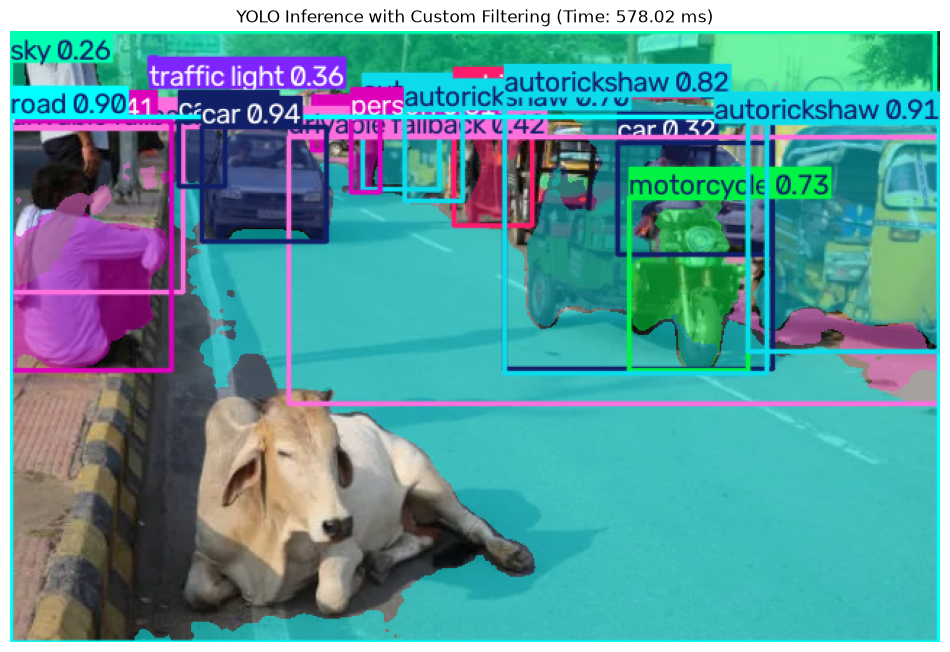

In [6]:
if os.path.exists(image_path):
    result = results[0]
    boxes = result.boxes
    
    print("\n--- Custom Filtering Results ---")
    valid_indices = []
    
    for i in range(len(boxes)):
        cls_id = int(boxes.cls[i])
        conf = float(boxes.conf[i])
        
        # 2. Apply Custom Rules:
        
        # If it's an animal (class 0), accept it even if confidence is low (e.g., > 10%)
        if cls_id == 0 and conf > 0.10:
            print(f"Found an Animal (class 0)! Confidence: {conf:.2f}")
            valid_indices.append(i)
            
        # If it's the dominant fallback class (class 10), only accept it if it's extremely confident (e.g., > 85%)
        elif cls_id == 10 and conf > 0.85:
            print(f"Found an Obstacle (class 10). Confidence: {conf:.2f}")
            valid_indices.append(i)
            
        # For all other classes, apply a standard threshold (e.g., > 25%)
        elif cls_id not in [0, 10] and conf > 0.25:
            print(f"Found class {cls_id}. Confidence: {conf:.2f}")
            valid_indices.append(i)

    # Create a new filtered result object containing only the valid indices
    filtered_result = result[valid_indices]
    
    # Generate an image array with all valid annotations drawn on it.
    res_plotted = filtered_result.plot()  # Returns a BGR numpy array

    # Convert BGR (OpenCV format) to RGB (Matplotlib format)
    res_plotted_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.figure(figsize=(12, 12))
    plt.imshow(res_plotted_rgb)
    plt.axis('off')
    plt.title(f"YOLO Inference with Custom Filtering (Time: {inference_time * 1000:.2f} ms)")
    plt.show()